# Startup

In [1]:
# Computer Vision Course (CSE 40535)
#
# Semester Project -- Leaf Classification
#
# Author: Xavier Reese 2024
#
# Part 3 -- Pre-Processing, Segmentation & Feature Extraction

In [2]:
#@title Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
################
#@title Install
!apt-get install python3.5
#!pip uninstall -y opencv-python-headless opencv-python opencv-contrib-python
#!pip install opencv-python-headless==4.5.5.62+contrib-cuda -f https://download.opencv.org/releases.html
#!pip install opencv-python==4.8.1.78
!apt-get update
!apt-get install -y python3.5 # Install python 3.5 if needed by your project

# Install system dependencies for CUDA
!apt-get install -y --no-install-recommends \
    cuda-11-8 \
    libcublas-11-8 \
    libcudnn8

# Uninstall conflicting versions of OpenCV if they exist
!pip uninstall -y opencv-python-headless opencv-python opencv-contrib-python

# Install OpenCV with CUDA support
#!pip install opencv-python-headless==4.5.5.62+contrib-cuda -f https://download.opencv.org/releases.html
!pip install opencv-python-headless[cuda]

import numpy as np
import math
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import skimage.measure as measure

print(cv2.__version__)
print("CUDA Support in OpenCV:", cv2.cuda.getCudaEnabledDeviceCount() > 0)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libpython3.5-stdlib' for regex 'python3.5'
Note, selecting 'libpython3.5-minimal' for regex 'python3.5'
0 upgraded, 0 newly installed, 0 to remove and 52 not upgraded.
Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy

In [4]:
## IMPORT IMAGES

import glob

orig_leaves = {}
path = "/content/drive/MyDrive/healthy/*" ### <=== UPDATE THIS TO DESIRED FOLDER
for folder in glob.glob(path):
    folder_name = folder.split('/')[-1]
    print('importing: ', folder_name)
    orig_leaves[folder_name] = []
    i = 0
    for img in glob.glob(folder+"/*"):
        i+=1
        if(i%100 == 0): print(i)
        if(i == 1000): break
        orig_leaves[folder_name].append(cv2.imread(img))
    print('-- done --')

importing:  Apple
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Cherry
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Soybean
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Pepper
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Grape
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Peach
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Blueberry
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Raspberry
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Potato
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Strawberry
100
200
300
400
500
600
700
800
900
1000
-- done --
importing:  Tomato
100
200
300
400
500
600
700
800
900
1000
-- done --


# Processing

In [5]:
#################################
#@title GENERAL USE HELPER FUNCTIONS

def equalize(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.equalizeHist(gray)

def equalize_clahe_gray(gray_img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(gray_img)

def equalize_clahe(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return equalize_clahe_gray(gray)


In [6]:
################################
#@title EXTRACT BINARY THRESH OF LEAF

def binary_leaf_green_rgb(image):
    r, g, b = cv2.split(image)
    # Threshold -> Binary of Leaf (green only)
    ret_leaf, thresh_leaf = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return ret_leaf, thresh_leaf

def binary_leaf_green_hsv(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    # Threshold -> Binary of Leaf (green only)
    lower_bounds = np.array([35, 20, 0])
    upper_bounds = np.array([100, 255, 255])
    mask = cv2.inRange(hsv, lower_bounds, upper_bounds)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel=np.ones((5,5), np.uint8))

    return mask

def binary_leaf_grey(image):
    gray = equalize(image)
    gray = equalize_clahe(image)
    # Threshold -> Binary of Leaf
    ret_leaf, thresh_leaf = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return ret_leaf, thresh_leaf

def binary_shadow(image):
    se_size = 2  # size of your structuring element (morphological operation kernel) -- try something between 5 and 15
    se = np.ones((se_size,se_size), np.uint8)
    gray = equalize_clahe(image)

    ret_shadow, thresh_shadow = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY_INV)

    # bounds for shadow
    shadow_lower_bounds = np.array([0, 0, 0])
    shadow_upper_bounds = np.array([255, 90, 30])

    # Erode & Dilate
    thresh_shadow = cv2.morphologyEx(thresh_shadow, cv2.MORPH_ERODE, kernel=se)
    thresh_shadow = cv2.morphologyEx(thresh_shadow, cv2.MORPH_DILATE, kernel=se)

    return ret_shadow, thresh_shadow




In [7]:
###################
#@title REMOVE SHADOWS

def shadow_mask(image):
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Threshold to isolate non-shadow areas (higher Value)
    _, mask = cv2.threshold(hsv_image[:, :, 2], 30, 255, cv2.THRESH_BINARY)

    #plt.imshow(mask, cmap='gray')
    #plt.show()
    return mask


In [8]:
#@title BINARY LEAF USING EDGE DETECTION

def edge_leaf_adaptive(image):
    blurred_image = cv2.GaussianBlur(image, (5, 5), 0)
    gray = cv2.cvtColor(blurred_image, cv2.COLOR_BGR2GRAY)
    adaptive_thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    median_blurred = cv2.medianBlur(adaptive_thresh, 7) # less noise
    edges = cv2.Canny(median_blurred, 50, 150)

    ## Show Adaptive Threshold Steps
    '''
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 4, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(adaptive_thresh, cmap='gray')
    plt.title("Adaptive Threshold")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(median_blurred, cmap='gray')
    plt.title("Median Blur")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(edges, cmap='gray')
    plt.title("Edges Detected")
    plt.axis("off")

    plt.show()
    '''

def edge_leaf(image):
    blurred_image = cv2.GaussianBlur(image, (5, 5), 0)
    gray = cv2.cvtColor(blurred_image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(blurred_image, threshold1=100, threshold2=200)
    without_shadow = cv2.bitwise_and(edges, shadow_mask(image))

    ## Show Edge Detection Steps
    '''
    plt.figure(figsize=(10,5))
    plt.subplot(1, 4, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(edges, cmap='gray')
    plt.title("Edges Detected")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(without_shadow, cmap='gray')
    plt.title("Without Shadows")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(gray, cmap='gray')
    plt.title("Gray Image")
    plt.axis("off")

    plt.show()
    '''

In [9]:
####################
#@title Post-Binarization

def remove_stems(img):
    kernel = np.ones((10, 10), np.uint8)
    opened_image = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(opened_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    leaf_bin = np.zeros_like(img)
    for contour in contours:
        if cv2.contourArea(contour) > 500:
            cv2.drawContours(leaf_bin, [contour], -1, 255, thickness=cv2.FILLED)
            break

    return leaf_bin

In [10]:
############################
#@title Extract Features

from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

def extract_features(bin_img, orig_img):
    features = dict()

    contours, _ = cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    perimeter = cv2.arcLength(contours[0], True)
    with_perimeter = cv2.drawContours(orig_img.copy(), contours, -1, (0, 255, 0), 3)
    features['perimeter'] = perimeter

    c_hull = find_convex_hull(contours)
    features['area'] = cv2.contourArea(c_hull)
    features['perimeter'] = cv2.arcLength(c_hull, True)

    area_shape = cv2.contourArea(max(cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0], key=cv2.contourArea))
    features['solidity'] = float(area_shape) / features['area'] if features['area'] != 0 else 0

    features['major_axis_length'], features['minor_axis_length'] = major_minor_axis(bin_img, c_hull)
    features['aspect_ratio'] = features['major_axis_length'] / features['minor_axis_length']

    features.update(extract_texture_features(orig_img, bin_img))
    features.update(extract_color_features(orig_img, bin_img))

    return features

def find_convex_hull(contours):
    largest_contour = max(contours, key=cv2.contourArea)
    hull = cv2.convexHull(largest_contour)

    return hull

def major_minor_axis(bin_img, convex_hull):
    binary_convex = np.zeros_like(bin_img)
    cv2.drawContours(binary_convex, [convex_hull], -1, 255, thickness=cv2.FILLED)

    # Pad image so if binary leaf goes over edge, we don't get multiple labels for background

    binary_convex_padded = np.pad(binary_convex, pad_width=1, mode='constant', constant_values=0)
    labels_padded = measure.label(binary_convex_padded)
    labels = labels_padded[1:-1, 1:-1] # un-pad

    # Measure Features
    features = measure.regionprops(labels)

    return features[0].major_axis_length, features[0].minor_axis_length

def extract_color_features(orig_img, bin_img):
    leaf_region = cv2.bitwise_and(orig_img, orig_img, mask=bin_img)
    hsv = cv2.cvtColor(leaf_region, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    average_h = np.mean(h)
    average_s = np.mean(s)
    average_v = np.mean(v)

    return {'average_h': average_h, 'average_s': average_s, 'average_v': average_v}


def extract_texture_features(orig_img, bin_img):
    gray_image = cv2.cvtColor(orig_img, cv2.COLOR_BGR2GRAY)
    gray_image = equalize_clahe_gray(gray_image)
    leaf_region = cv2.bitwise_and(gray_image, gray_image, mask=bin_img)

    ## Plot shown in README
    #plt.subplot(2, 3, 5)
    #plt.imshow(leaf_region, cmap="gray")

    #gpu_leaf_region = cv2.cuda_GpuMat()
    #gpu_leaf_region.upload(leaf_region)

    ### Gray-Level Co-Occurrence Matrix (GLCM) Features

    distances = [1, 3, 5]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]  # 0, 45, 90, 135

    glcm = graycomatrix(leaf_region, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast').mean()
    dissimilarity = graycoprops(glcm, 'dissimilarity').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()
    energy = graycoprops(glcm, 'energy').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    asm = graycoprops(glcm, 'ASM').mean()

    glcm_features = {'contrast': contrast, 'dissimilarity': dissimilarity, 'homogeneity': homogeneity, 'energy': energy, 'correlation': correlation, 'ASM': asm}

    ### Local Binary Pattern (LBP) Features

    radius = 3
    n_points = 8 * radius

    lbp = local_binary_pattern(leaf_region, n_points, radius, method="uniform")

    (lbpn, _) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    lbp_hist = lbpn.astype("float")
    lbp_hist /= (lbp_hist.sum())

    ### Gabor Filter Features

    num_orientations = 8

    gabor_means = []
    gabor_std = []
    filtered_max = np.zeros_like(bin_img)

    #height, width = bin_img.shape
    #gpu_filtered_or_img = cv2.cuda_GpuMat()
    #gpu_filtered_or_img.create((height, width), cv2.CV_8UC1)

    for theta in np.arange(0, np.pi, np.pi / num_orientations):
        if theta == np.pi / 4 or theta == 3 * np.pi / 4: continue  # skip 45 degree angles - much more difficult to tune and line features were picked up without them

        # Define Parameters
        sigma = 5
        ksize = 9 if theta == 0 or theta == np.pi / 2 else 13
        gamma = 0.01
        lambda_ = 5
        kernel = cv2.getGaborKernel((ksize, ksize), sigma, theta, 8.0, 0.5, 0, ktype=cv2.CV_32F)

        # Perform Filter
        filtered = cv2.filter2D(leaf_region, cv2.CV_8UC3, kernel)

        #gpu_filtered = cv2.cuda.filter2D(gpu_leaf_region, -1, cv2.cuda_Kernel(kernel))
        '''
        print("sigma", sigma, "theta", theta, "lambda", lambda_, "gamma", gamma, "ksize", ksize)
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(kernel, cmap='gray')
        plt.colorbar()
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(filtered, cmap='gray')
        plt.colorbar()
        plt.axis("off")
        plt.show()
        '''


        ## Max Results Together

        #filtered_and_bin = cv2.bitwise_or(filtered_and_bin, filtered, mask=bin_img)
        filtered_max = cv2.max(filtered_max, filtered)
        #gpu_filtered_or_img = cv2.cuda.bitwise_or(gpu_filtered_or_img, gpu_filtered, mask=gpu_leaf_region)
        mean, std_dev = cv2.meanStdDev(filtered, mask=bin_img)
        gabor_means.append(mean[0][0])
        gabor_std.append(std_dev[0][0])

    #filtered_max = gpu_filtered_or_img.download()

    ## Erode leaf edge and find mean/std of vein skeleton

    eroded_bin = cv2.erode(bin_img, np.ones((9, 9), np.uint8), iterations=1)
    filtered_max = cv2.bitwise_and(filtered_max, filtered_max, mask=eroded_bin)
    max_std, max_mean = cv2.meanStdDev(filtered_max, mask=eroded_bin)
    gabor_features = {'gabor_mean_sum': sum(gabor_means), 'gabor_std_sum': sum(gabor_std), 'gabor_mean_max': max_mean[0][0], 'gabor_std_max': max_std[0][0]}


    ## Show Vein Skeleton
    #cv2_imshow(filtered_max)

    ## Plot shown in README
    #plt.subplot(2, 3, 6)
    #plt.imshow(filtered_max, cmap="gray")

    all_features = {**glcm_features, **gabor_features, 'lbp_hist': lbp_hist}
    return all_features





In [11]:
#########################
#@title Final Functions

def binary_thresh_leaf(bin_img, orig_img):
    print("ORIGINAL:")
    cv2_imshow(bin_img)

    ret_leaf, thresh_leaf = binary_leaf_grey(bin_img)
    ret_shadow, thresh_shadow = binary_shadow(bin_img)

    #print("LEAF")
    #cv2_imshow(thresh_leaf)
    #print("SHADOW")
    #cv2_imshow(thresh_shadow)

    thresh = cv2.subtract(thresh_leaf, thresh_shadow)
    #print("FINAL")
    #cv2_imshow(thresh)

def binary_leaf_hsv(bin_img):
    #cv2_imshow(bin_img)
    green = binary_leaf_green_hsv(bin_img)
    #plt.subplot(2, 3, 2)
    #plt.imshow(green, cmap="gray")
    without_stems = remove_stems(green)
    return without_stems




# Extraction

In [12]:
########################
#@title Test / Display
import seaborn as sns
bin_images = []
bin_images_Y = []

leaf_data = dict()
def show(leaf_type):
    leaf_data[leaf_type] = []
    total = 30
    if leaf_type == 'Corn': return # removed because not in desired model behavior
    #if leaf_type != "Peach": return
    print(f'{leaf_type}')
    for i in range(total-1):
        img = orig_leaves[leaf_type][i].copy()
        bin_img = binary_leaf_hsv(img)
        bin_images.append(bin_img)
        bin_images_Y.append(leaf_type)
        leaf_data[leaf_type].append(extract_features(bin_img, img))

        ## Plot shown in README
        #plt.subplot(2, 3, 1)
        #plt.imshow(img)
        #plt.subplot(2, 3, 3)
        #plt.imshow(bin_img, cmap="gray")
    #plt.show()



for leaf_type in orig_leaves:
    show(leaf_type)

'''
features_to_show = ['area', 'perimeter', 'solidity', 'major_axis_length', 'minor_axis_length', 'aspect_ratio', \
                    'contrast', 'homogeneity', \
                    'gabor_mean_max', 'gabor_std_max', 'average_h']
for feature_type in features_to_show:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=[key for key in leaf_data.keys() for _ in range(len(leaf_data[key]))], y=[value[feature_type] for key in leaf_data.keys() for value in leaf_data[key]])
    plt.xlabel('Leaf Type')
    plt.ylabel(feature_type)
    plt.title(str(feature_type) + ' distribution by leaf type')
    plt.show()
# display single lbp histogram
lbpn = leaf_data['Apple'][0]['lbp_hist']
plt.bar(range(len(lbpn)), lbpn)
plt.title("LBP HISTOGRAM")
plt.show()
'''


Apple
Cherry
Soybean
Pepper
Grape
Peach
Blueberry
Raspberry
Potato
Strawberry
Tomato


'\nfeatures_to_show = [\'area\', \'perimeter\', \'solidity\', \'major_axis_length\', \'minor_axis_length\', \'aspect_ratio\',                     \'contrast\', \'homogeneity\',                     \'gabor_mean_max\', \'gabor_std_max\', \'average_h\']\nfor feature_type in features_to_show:\n    plt.figure(figsize=(10, 5))\n    sns.boxplot(x=[key for key in leaf_data.keys() for _ in range(len(leaf_data[key]))], y=[value[feature_type] for key in leaf_data.keys() for value in leaf_data[key]])\n    plt.xlabel(\'Leaf Type\')\n    plt.ylabel(feature_type)\n    plt.title(str(feature_type) + \' distribution by leaf type\')\n    plt.show()\n# display single lbp histogram\nlbpn = leaf_data[\'Apple\'][0][\'lbp_hist\']\nplt.bar(range(len(lbpn)), lbpn)\nplt.title("LBP HISTOGRAM")\nplt.show()\n'

# Classification

In [13]:
#@title Imports / Constants
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tensorflow.keras.callbacks import EarlyStopping

leaf_types = list(leaf_data.keys())  # ["apple", "grape", ... ]
type_to_label = {leaf_type: idx for idx, leaf_type in enumerate(leaf_types)}

batch_size = 16


In [36]:
#@title SVM Classification
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

results = []
X = []
Y = []
if('lbp_hist' in leaf_data['Apple'][0].keys()):
    for leaf_type, features in leaf_data.items():
        for feature in features:
            del feature['lbp_hist']

print(len(leaf_data['Apple'][0].keys()))

for leaf_type, features in leaf_data.items():
    X.extend(([list(f.values()) for f in features]))
    Y.extend([type_to_label[leaf_type]] * len(features))

X = np.array(X)
Y = np.array(Y)

'''
for pca_dim in [3]:
    print("PCA_DIM: ", pca_dim)
    pca = PCA(n_components=pca_dim)
    X_post = pca.fit_transform(X)
'''
scalar = StandardScaler()
X_post = scalar.fit_transform(X)

def fit(X, y, clf):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'RBF Accuracy on Leaves: {accuracy:.2f}')

fit(X_post, Y, SVC(kernel='rbf', decision_function_shape='ovr'))
del X
del Y
del X_post

19
RBF Accuracy on Leaves: 0.65


## Statistics -> Classification

In [14]:
#@title Define Model
def train_model(pca_dim, data_x, data_y):
    print("PCA_DIM: ", pca_dim)
    pca = PCA(n_components=pca_dim)
    X_post = pca.fit_transform(data_x)
    #scalar = StandardScaler()
    #X_post = scalar.fit_transform(X)
    y_post = to_categorical(data_y)


    X_train, X_test, y_train, y_test = train_test_split(X_post, y_post, test_size=0.2, random_state=42)

    print(len(X_train))

    model = Sequential([
        Dense(64, input_dim=X_post.shape[1], activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(11, activation='softmax')
    ])

    model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

    history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=batch_size)

    loss, accuracy = model.evaluate(X_test, y_test)
    results.append([pca_dim, accuracy])



19
PCA_DIM:  2
255


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 350ms/step - accuracy: 0.1255 - loss: 630.0588 - val_accuracy: 0.1765 - val_loss: 143.9796
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1384 - loss: 129.2994 - val_accuracy: 0.1373 - val_loss: 85.8418
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2147 - loss: 76.8819 - val_accuracy: 0.1569 - val_loss: 82.1699
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1235 - loss: 69.3883 - val_accuracy: 0.1569 - val_loss: 85.6142
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2314 - loss: 59.5513 - val_accuracy: 0.3333 - val_loss: 115.5768
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2564 - loss: 66.3414 - val_accuracy: 0.2941 - val_loss: 50.8453
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2830 - loss: 34.2279 - val_accuracy: 0.1373 - val_loss: 42.0221
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2313 - loss: 35.2938 - val_accurac

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.1236 - loss: 277.0756 - val_accuracy: 0.1961 - val_loss: 282.9853
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1833 - loss: 209.5642 - val_accuracy: 0.2157 - val_loss: 126.7862
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2867 - loss: 69.7336 - val_accuracy: 0.1961 - val_loss: 79.7163
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2478 - loss: 57.1408 - val_accuracy: 0.2157 - val_loss: 75.6841
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2646 - loss: 43.5674 - val_accuracy: 0.1961 - val_loss: 76.5946
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2265 - loss: 43.1705 - val_accuracy: 0.2353 - val_loss: 70.3683
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2109 - loss: 45.9298 - val_accuracy: 0.1961 - val_loss: 58.2965
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3026 - loss: 36.3440 - val_accuracy: 0.3137 -

...

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.1120 - loss: 338.8119 - val_accuracy: 0.1765 - val_loss: 118.9397
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1840 - loss: 96.3958 - val_accuracy: 0.0980 - val_loss: 68.0258
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1314 - loss: 51.5738 - val_accuracy: 0.2353 - val_loss: 50.7700
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2103 - loss: 45.9895 - val_accuracy: 0.3137 - val_loss: 64.9450
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2323 - loss: 37.5875 - val_accuracy: 0.2353 - val_loss: 28.4711
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2982 - loss: 21.1451 - val_accuracy: 0.3529 - val_loss: 21.5440
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2402 - loss: 17.9274 - val_accuracy: 0.4118 - val_loss: 22.7598
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2558 - loss: 18.6043 - val_accuracy: 0.2549 - v

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.0852 - loss: 369.1538 - val_accuracy: 0.1373 - val_loss: 171.6940
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1070 - loss: 128.6804 - val_accuracy: 0.1765 - val_loss: 97.1480
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1222 - loss: 68.4615 - val_accuracy: 0.2941 - val_loss: 64.6988
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2423 - loss: 46.5545 - val_accuracy: 0.2353 - val_loss: 78.3030
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2504 - loss: 54.2006 - val_accuracy: 0.2157 - val_loss: 64.9200
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2582 - loss: 45.2917 - val_accuracy: 0.1569 - val_loss: 84.4928
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2385 - loss: 40.8267 - val_accuracy: 0.1373 - val_loss: 50.4289
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2541 - loss: 36.9045 - val_accuracy: 0.2353 - 

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.0780 - loss: 514.5084 - val_accuracy: 0.1373 - val_loss: 153.3412
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1516 - loss: 113.9361 - val_accuracy: 0.2549 - val_loss: 86.5694
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2045 - loss: 56.3478 - val_accuracy: 0.2157 - val_loss: 76.1948
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2286 - loss: 47.9730 - val_accuracy: 0.2745 - val_loss: 59.3099
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2389 - loss: 35.2019 - val_accuracy: 0.3333 - val_loss: 31.1649
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2272 - loss: 25.7435 - val_accuracy: 0.2157 - val_loss: 43.2794
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2920 - loss: 26.7084 - val_accuracy: 0.1373 - val_loss: 41.8997
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2589 - loss: 30.6826 - val_accuracy: 0.2353 - 

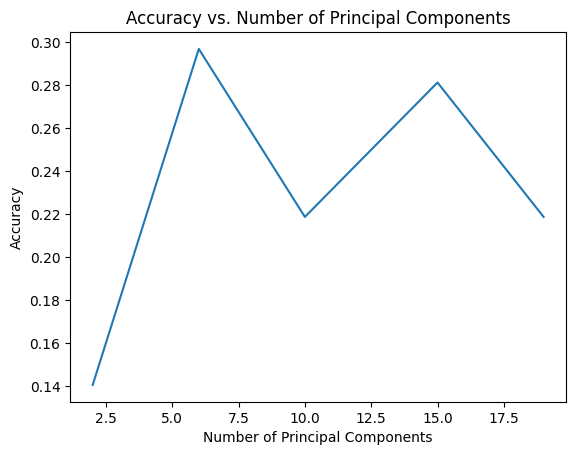

In [15]:
#@title Train Model
from tensorflow.keras import backend as K
import gc

K.clear_session()
gc.collect()


X = []
Y = []

if('lbp_hist' in leaf_data['Apple'][0].keys()):
    for leaf_type, features in leaf_data.items():
        for feature in features:
            del feature['lbp_hist']

print(len(leaf_data['Apple'][0].keys()))

for leaf_type, features in leaf_data.items():
    X.extend(([list(f.values()) for f in features]))
    Y.extend([type_to_label[leaf_type]] * len(features))

X = np.array(X)
Y = np.array(Y)

results = []
for pca_dim in [2, 6, 10, 15, 19]:
    train_model(pca_dim, X, Y)


results = np.array(results)
plt.plot(results[:, 0], results[:, 1])
plt.xlabel('Number of Principal Components')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Number of Principal Components')
plt.show()

del X
gc.collect()

## Processed Photo -> Classification

In [16]:
#@title Define Model
def train_model_post_process(data_x, data_y):
    print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
    y_post = to_categorical(data_y)

    X_train, X_test, y_train, y_test = train_test_split(data_x, y_post, test_size=0.2, random_state=42)

    input_shape = (256, 256, 1)

    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.8),
        Dense(11, activation='softmax')
    ])

    model.summary()

    model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    with tf.device('/GPU:0'):
        history = model.fit(X_train, y_train, validation_split=0.2, epochs=20, batch_size=batch_size, callbacks=[early_stopping])

    loss, accuracy = model.evaluate(X_test, y_test)

    return loss, accuracy

In [17]:
#@title Train Model
from tensorflow.keras import backend as K
import gc

K.clear_session()
gc.collect()
type_to_label = {leaf_type: idx for idx, leaf_type in enumerate(leaf_types)}

Y = []
for i in range(len(bin_images_Y)):
    Y.append(type_to_label[bin_images_Y[i]])



print("INPUT SHAPE:")
print(bin_images[0].shape)
bin_images_reshaped = np.array([cv2.resize(img, (256, 256)) for img in bin_images])
bin_images_reshaped = bin_images_reshaped.reshape(-1, 256, 256, 1)
bin_images_reshaped = bin_images_reshaped / 255.0
loss, accuracy = train_model_post_process(bin_images_reshaped, Y)

print(f"Loss: {loss}, Accuracy: {accuracy}")

del bin_images_reshaped
gc.collect()

INPUT SHAPE:
(256, 256)
Num GPUs Available:  1
255


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 246016)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │      15,745,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 11)                  │             715 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,764,619 (60.14 MB)

 Trainable params: 15,764,619 (60.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 295ms/step - accuracy: 0.0593 - loss: 5.7568 - val_accuracy: 0.0980 - val_loss: 2.3981
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1208 - loss: 2.3917 - val_accuracy: 0.0784 - val_loss: 2.3866
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1249 - loss: 2.3636 - val_accuracy: 0.0196 - val_loss: 2.3730
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1315 - loss: 2.2961 - val_accuracy: 0.2157 - val_loss: 2.2812
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1855 - loss: 2.1491 - val_accuracy: 0.3529 - val_loss: 2.1471
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2419 - loss: 1.9603 - val_accuracy: 0.3529 - val_loss: 2.0669
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2173 - loss: 2.0051 - val_accuracy: 0.3333 - val_loss: 2.0788
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2276 - loss: 1.9435 - val_accuracy: 0.4118 - v

## Original Images -> Classification

In [66]:
#@title Define Model
def train_model_original(data_x, data_y):
    print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
    y_post = to_categorical(data_y)

    X_train, X_test, y_train, y_test = train_test_split(data_x, y_post, test_size=0.2, random_state=42)

    print(len(X_train))

    input_shape = (256, 256, 1)

    model = Sequential([
        Conv2D(32, (5, 5), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(11, activation='softmax')
    ])

    model.summary()

    model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    with tf.device('/GPU:0'):
        history = model.fit(X_train, y_train, validation_split=0.2, epochs=30, batch_size=batch_size, callbacks=[early_stopping])

    loss, accuracy = model.evaluate(X_test, y_test)

    del model
    del history
    del X_train
    del X_test
    del y_train
    del y_test
    gc.collect()

    return loss, accuracy

In [67]:
#@title Organize Data
type_to_label = {leaf_type: idx for idx, leaf_type in enumerate(leaf_types)}
if('orig_X' in locals()):
    del orig_X
    del Y
    gc.collect()
orig_X = []
Y = []

print("INPUT SHAPE:")
print(orig_leaves["Apple"][0].shape)
for leaf_type, leaves in orig_leaves.items():
    for leaf in leaves:
        orig_X.append(equalize(cv2.resize(leaf, (256, 256))))
        #orig_X.append(cv2.resize(leaf, (256, 256)))
        Y.append(type_to_label[leaf_type])

orig_X = np.array(orig_X)
Y = np.array(Y)

INPUT SHAPE:
(256, 256, 3)


In [68]:
#@title Train Model
from tensorflow.keras import backend as K
import gc

K.clear_session()
gc.collect()
orig_reshaped = orig_X.reshape(-1, 256, 256, 1)
orig_reshaped = orig_reshaped / 255.0
loss, accuracy = train_model_original(orig_reshaped, Y)

print(f"Loss: {loss}, Accuracy: {accuracy}")
del orig_reshaped
del orig_X
del Y
gc.collect()

Num GPUs Available:  1
8791


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 252, 252, 32)        │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 126, 126, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 124, 124, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       6,422,592 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 11)                  │             715 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,664,075 (25.42 MB)

 Trainable params: 6,664,075 (25.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.1427 - loss: 2.3396 - val_accuracy: 0.4804 - val_loss: 1.5388
Epoch 2/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4839 - loss: 1.5033 - val_accuracy: 0.6151 - val_loss: 1.0994
Epoch 3/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6244 - loss: 1.0718 - val_accuracy: 0.6805 - val_loss: 0.9446
Epoch 4/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7186 - loss: 0.7764 - val_accuracy: 0.7385 - val_loss: 0.7511
Epoch 5/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7900 - loss: 0.5972 - val_accuracy: 0.7686 - val_loss: 0.6816
Epoch 6/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8545 - loss: 0.4274 - val_accuracy: 0.7766 - val_loss: 0.6530
Epoch 7/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8765 - loss: 0.3444 - val_accuracy: 0.7834 - val_loss: 0.7220
Epoch 8/30
440/440 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9062 - loss: 0.2724 - val_accuracy: 

4720

## Original Images + Mask -> Classification

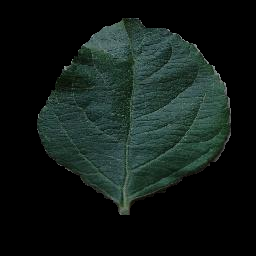

In [14]:
#@title Organize Data with mask
if('orig_X_mask' in locals()):
    del orig_X_mask
    del Y_mask
    gc.collect()
orig_X_mask = []
Y_mask = []

for leaf_type, leaves in orig_leaves.items():
    for leaf in leaves:
        leaf_mask = binary_leaf_hsv(leaf)
        #leaf = equalize(leaf)
        dilated_leaf_mask = cv2.dilate(leaf_mask, np.ones((50, 50), np.uint8), iterations=1)
        leaf = cv2.bitwise_and(leaf, leaf, mask=leaf_mask)
        leaf = cv2.resize(leaf, (256, 256))
        orig_X_mask.append(leaf)
        Y_mask.append(type_to_label[leaf_type])

cv2_imshow(orig_X_mask[0])

orig_X_mask = np.array(orig_X_mask)
Y_mask = np.array(Y_mask)

In [15]:
#@title Define Model
def train_model_original(data_x, data_y):
    print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
    y_post = to_categorical(data_y)

    X_train, X_test, y_train, y_test = train_test_split(data_x, y_post, test_size=0.2, random_state=42)

    print(len(X_train))

    input_shape = (256, 256, 3)

    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(256, (3, 3), activation='relu'),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.7),
        Dense(11, activation='softmax')
    ])

    model.summary()

    model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    with tf.device('/GPU:0'):  # Specify GPU device
        history = model.fit(X_train, y_train, validation_split=0.2, epochs=40, batch_size=batch_size, callbacks=[early_stopping])

    loss, accuracy = model.evaluate(X_test, y_test)

    del model
    del history
    del X_train
    del X_test
    del y_train
    del y_test
    gc.collect()

    return loss, accuracy

In [16]:
#@title Train Model
from tensorflow.keras import backend as K
import gc

K.clear_session()
gc.collect()
orig_reshaped = orig_X_mask.reshape(-1, 256, 256, 3)
orig_reshaped = orig_reshaped / 255.0
loss, accuracy = train_model_original(orig_reshaped, Y_mask)

print(f"Loss: {loss}, Accuracy: {accuracy}")
del orig_reshaped
del orig_X_mask
del Y_mask
gc.collect()

Num GPUs Available:  1
8791


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 200704)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │      12,845,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 11)                  │             715 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,234,251 (50.48 MB)

 Trainable params: 13,234,251 (50.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
440/440 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.1761 - loss: 2.2724 - val_accuracy: 0.5077 - val_loss: 1.5713
Epoch 2/40
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3169 - loss: 1.8198 - val_accuracy: 0.5293 - val_loss: 1.3438
Epoch 3/40
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3316 - loss: 1.7479 - val_accuracy: 0.5088 - val_loss: 1.3909
Epoch 4/40
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3571 - loss: 1.6884 - val_accuracy: 0.5298 - val_loss: 1.3036
Epoch 5/40
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3738 - loss: 1.6487 - val_accuracy: 0.6032 - val_loss: 1.0793
Epoch 6/40
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4205 - loss: 1.5068 - val_accuracy: 0.6441 - val_loss: 1.0195
Epoch 7/40
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4392 - loss: 1.4446 - val_accuracy: 0.6447 - val_loss: 0.9838
Epoch 8/40
440/440 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4661 - loss: 1.3602 - val_acc

4719